In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 150

DATA = 'D:/Deep_Learning/DeepGuard/data/CICIDS2017/'
VIS_DIR = 'D:/Deep_Learning/DeepGuard/visualizations/'

In [3]:
# 데이터 로드 (샘플링으로 메모리 절약)
files = {
    'Monday (BENIGN)':      DATA + 'Monday-WorkingHours.pcap_ISCX.csv',
    'Tuesday (BruteForce)': DATA + 'Tuesday-WorkingHours.pcap_ISCX.csv',
    'Wednesday (DoS)':      DATA + 'Wednesday-workingHours.pcap_ISCX.csv',
    'Friday (DDoS)':        DATA + 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
}

In [4]:
dfs = []
for name, path in files.items():
    df = pd.read_csv(path, encoding='utf-8')
    df.columns = df.columns.str.strip()
    label_col = 'Label' if 'Label' in df.columns else ' Label'
    df = df.rename(columns={label_col: 'Label'})
    df['source'] = name
    dfs.append(df)
    print(f"{name}: {len(df):,}개 로드 완료")

raw = pd.concat(dfs, ignore_index=True)
print(f"\n전체: {len(raw):,}개")
print(raw['Label'].value_counts())

Monday (BENIGN): 529,918개 로드 완료
Tuesday (BruteForce): 445,909개 로드 완료
Wednesday (DoS): 692,703개 로드 완료
Friday (DDoS): 225,745개 로드 완료

전체: 1,894,275개
Label
BENIGN              1499741
DoS Hulk             231073
DDoS                 128027
DoS GoldenEye         10293
FTP-Patator            7938
SSH-Patator            5897
DoS slowloris          5796
DoS Slowhttptest       5499
Heartbleed               11
Name: count, dtype: int64


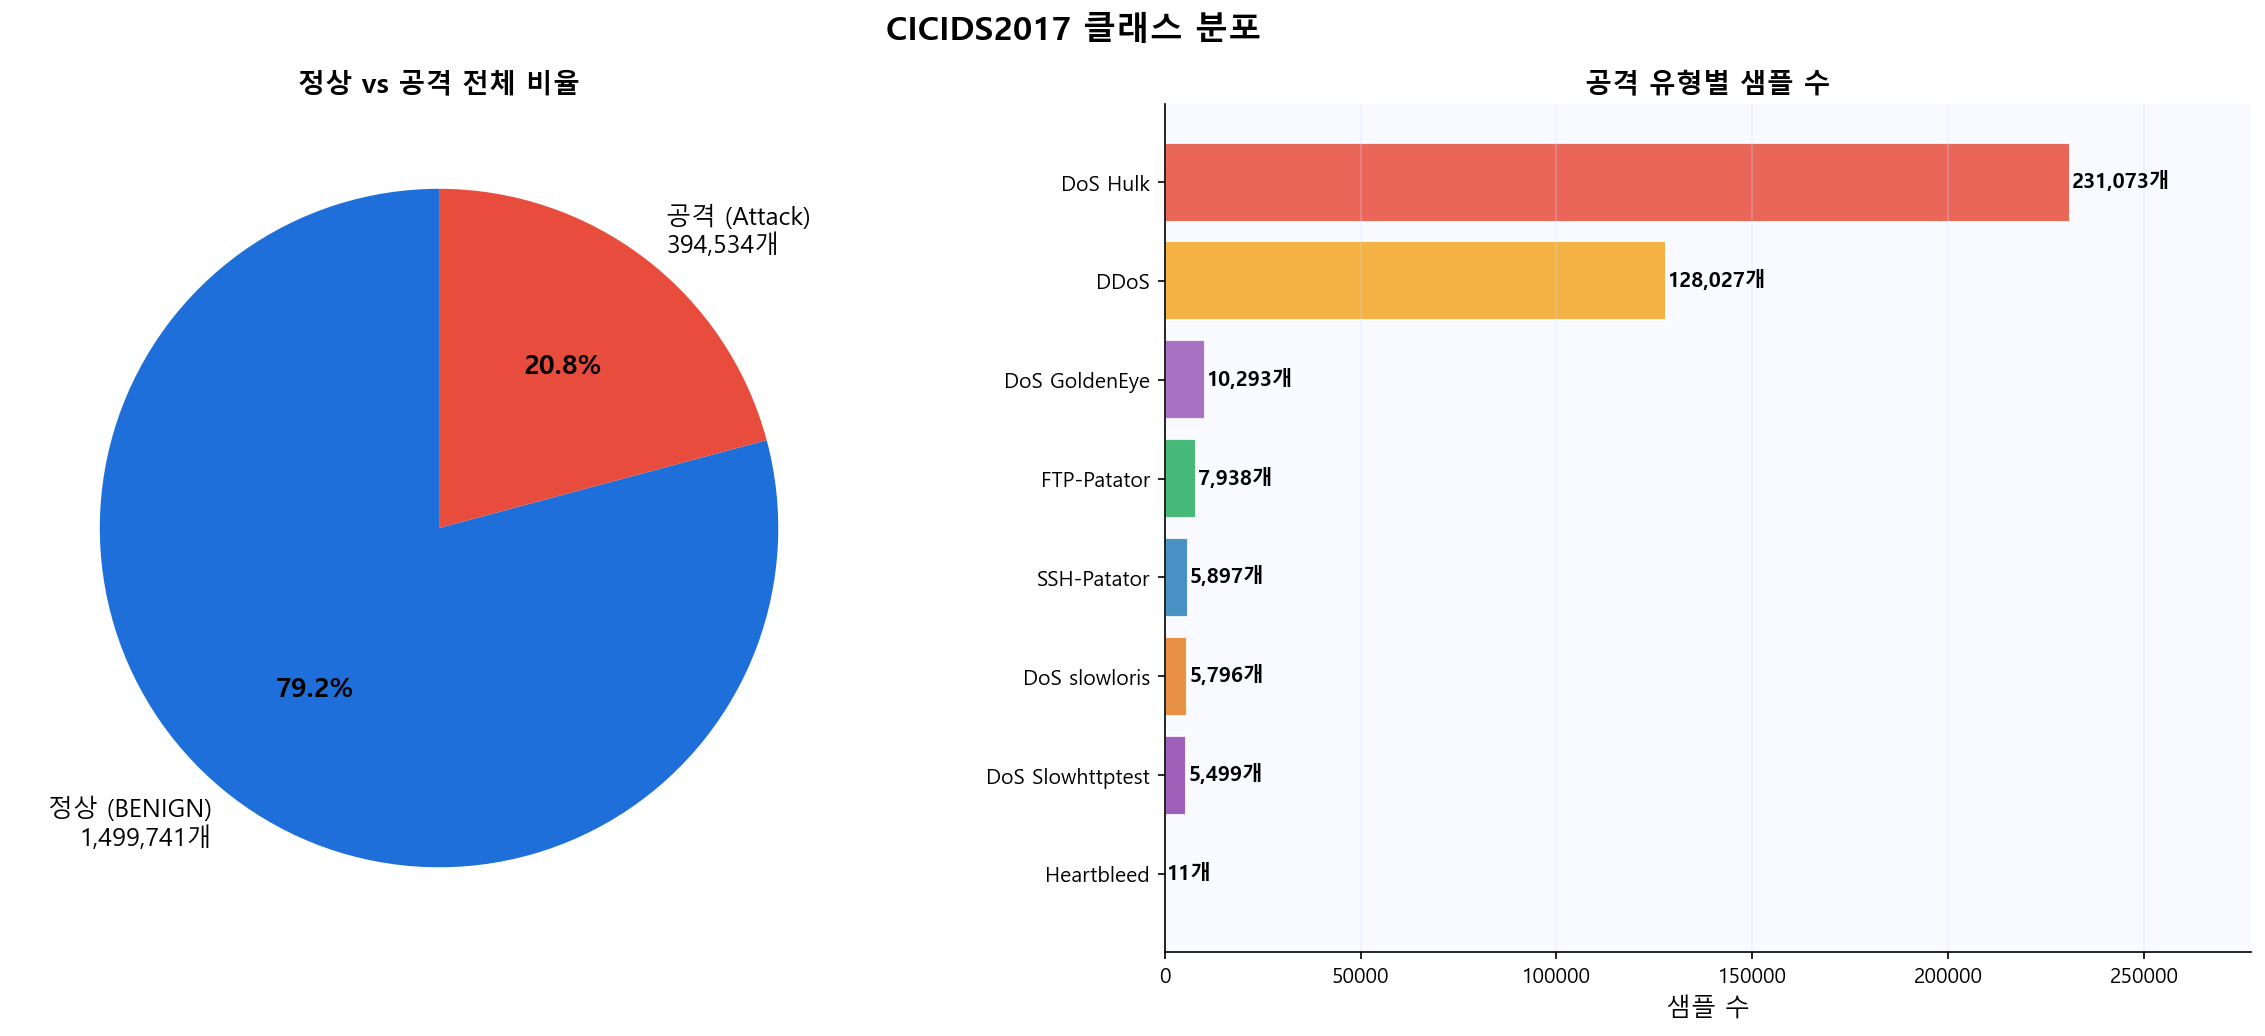

✅ EDA 1 저장 완료


In [7]:
# ── EDA 1. 클래스 불균형 시각화 ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('CICIDS2017 클래스 분포', fontsize=16, fontweight='bold')
fig.patch.set_facecolor('white')

# ── 왼쪽: 정상 vs 공격 파이차트 ──────────────────────────────
ax = axes[0]
label_counts = raw['Label'].apply(
    lambda x: '정상 (BENIGN)' if x == 'BENIGN' else '공격 (Attack)'
).value_counts()

colors = ['#1E6FD9', '#E74C3C']
wedges, texts, autotexts = ax.pie(
    label_counts.values,
    labels=[f'{k}\n{v:,}개' for k, v in label_counts.items()],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontweight('bold')
    at.set_fontsize(13)
ax.set_title('정상 vs 공격 전체 비율', fontsize=13, fontweight='bold')

# ── 오른쪽: 공격 유형별 바차트 ───────────────────────────────
ax = axes[1]
ax.set_facecolor('#F8FAFF')

attack_only = raw[raw['Label'] != 'BENIGN']['Label'].value_counts()
colors2 = ['#E74C3C', '#F5A623', '#9B59B6', '#27AE60',
           '#2980B9', '#E67E22', '#8E44AD', '#C0392B'][:len(attack_only)]

bars = ax.barh(attack_only.index[::-1], attack_only.values[::-1],
               color=colors2[::-1], alpha=0.85, edgecolor='white')

for bar, val in zip(bars, attack_only.values[::-1]):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'{val:,}개', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('샘플 수', fontsize=12)
ax.set_title('공격 유형별 샘플 수', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3, color='#CCDDFF')
ax.set_xlim(0, attack_only.max() * 1.2)

plt.tight_layout()
plt.savefig(VIS_DIR + 'eda1_class_distribution.png', bbox_inches='tight', facecolor='white')
plt.show()
print("✅ EDA 1 저장 완료")

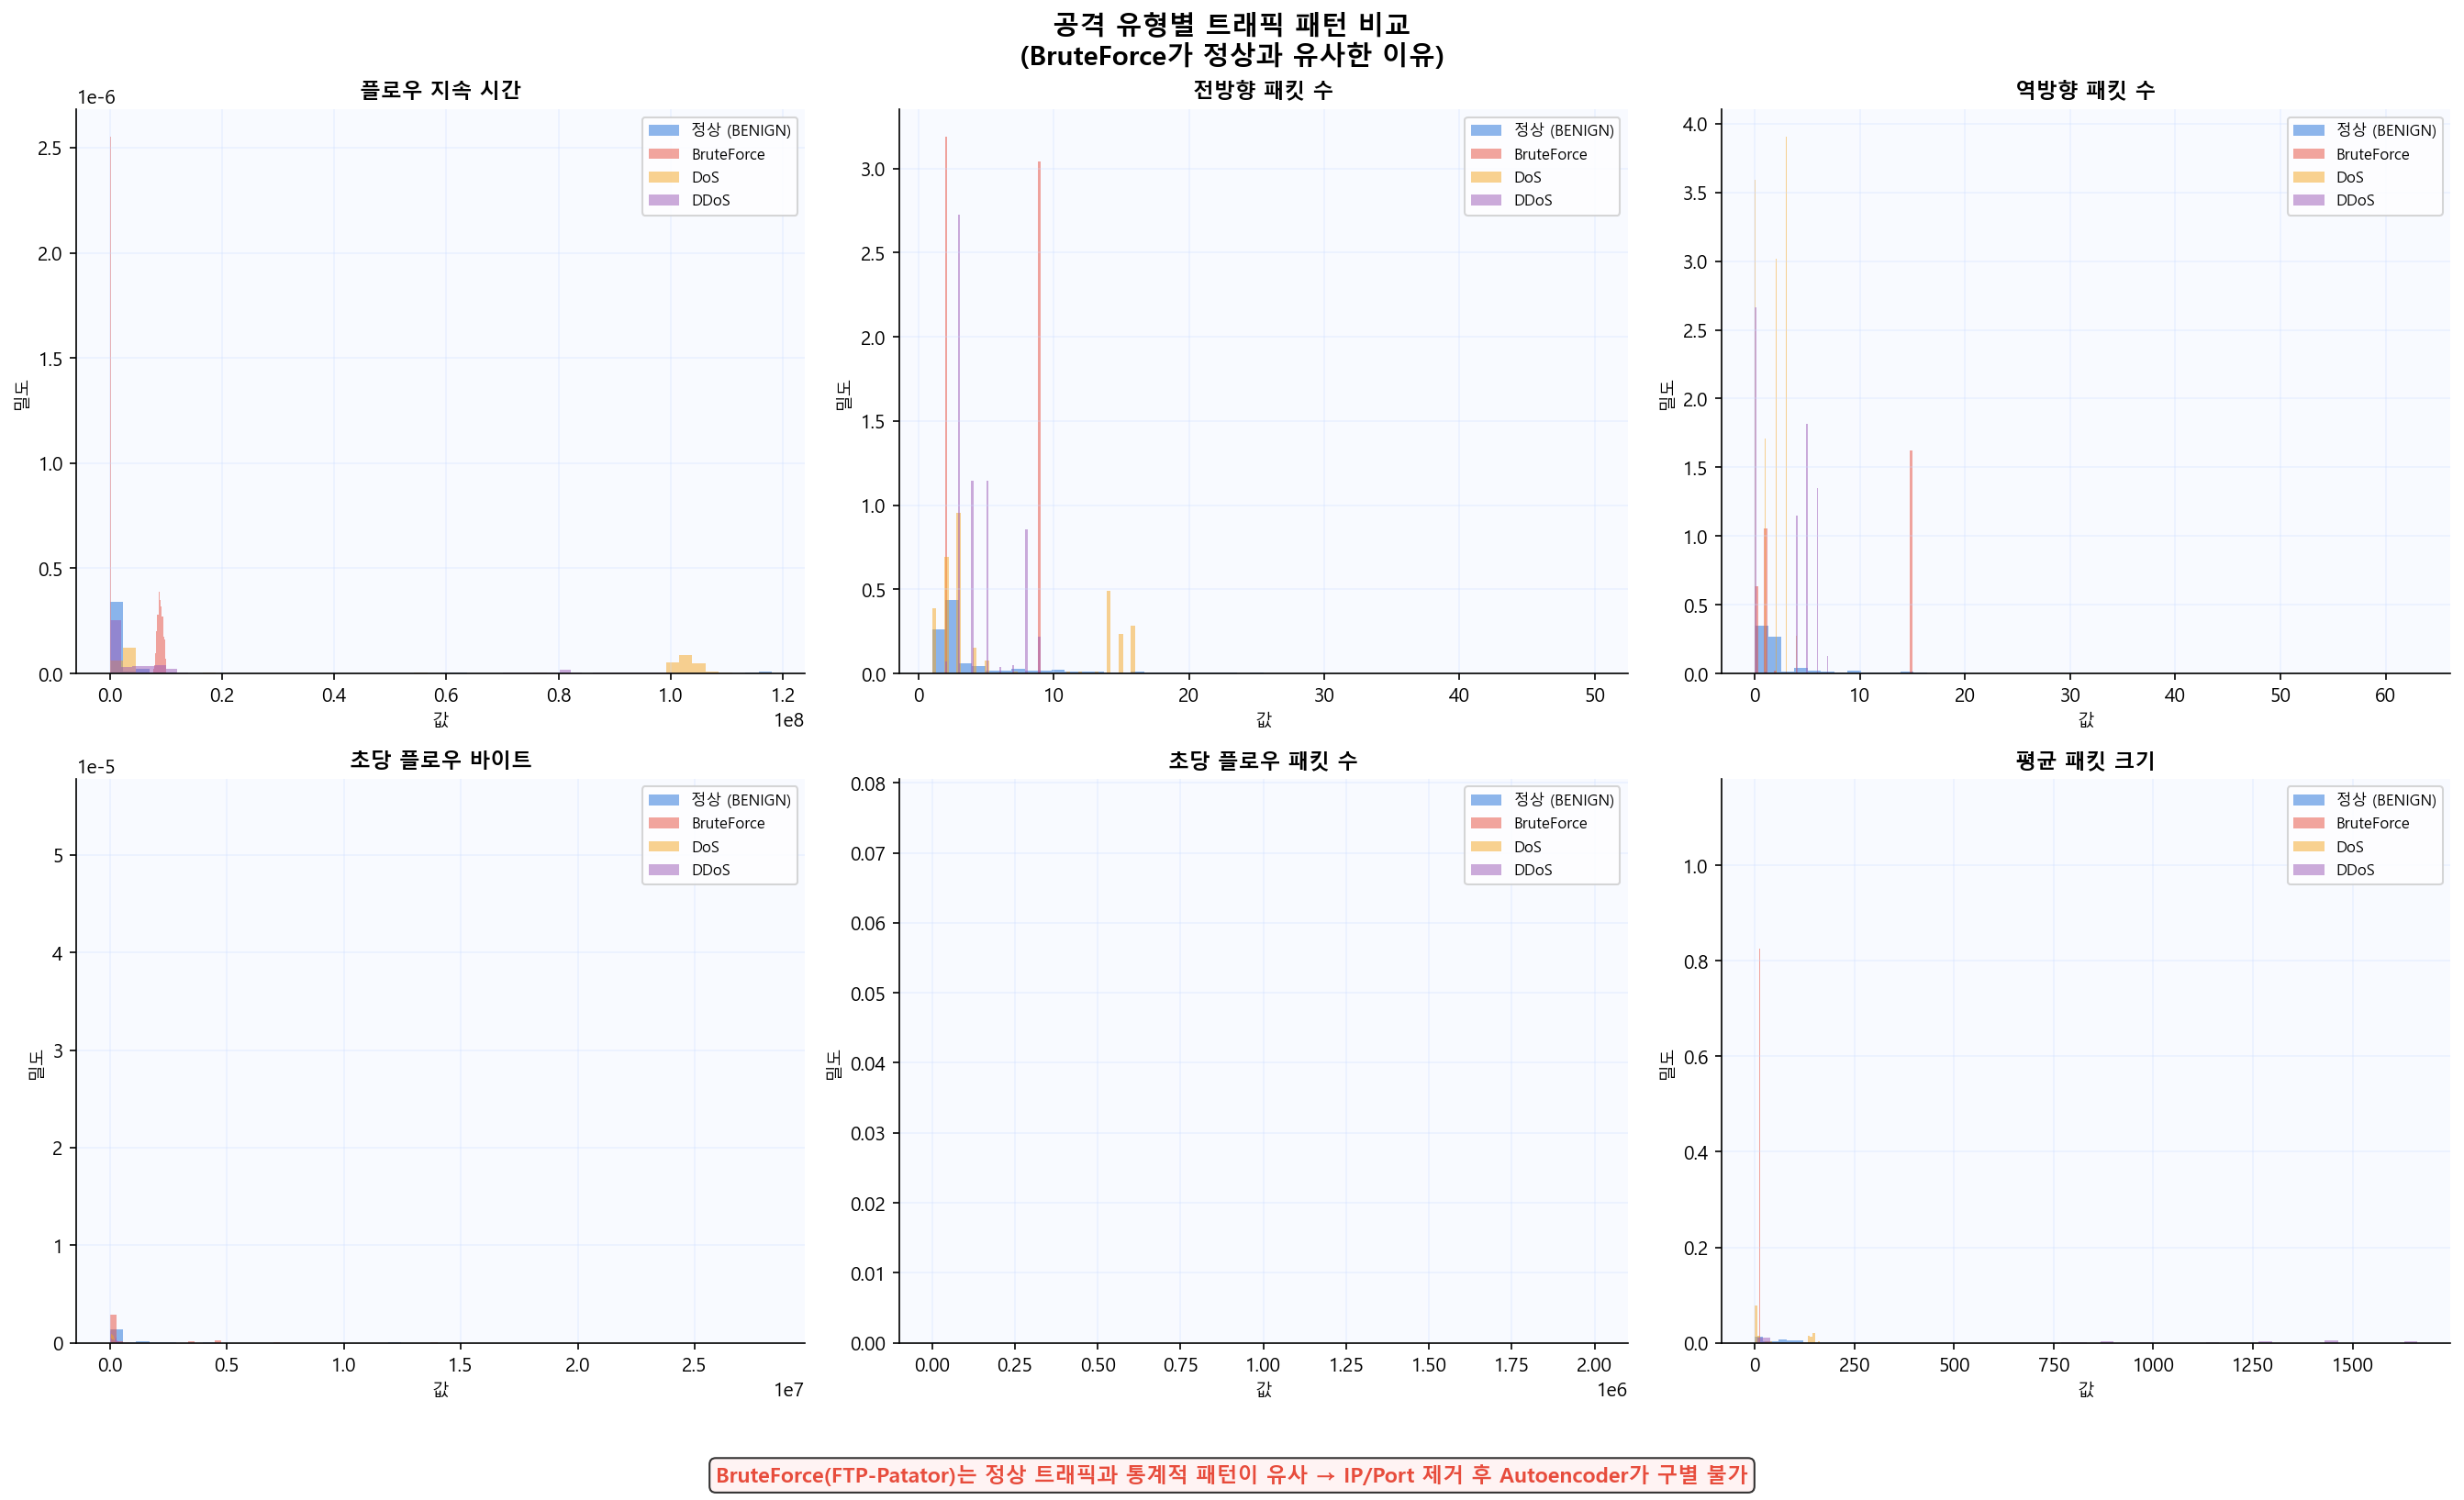

✅ EDA 2 저장 완료


In [5]:
# ── EDA 2. 공격 유형별 트래픽 패턴 비교 ──────────────────────
key_features = {
    'Flow Duration':          '플로우 지속 시간',
    'Total Fwd Packets':      '전방향 패킷 수',
    'Total Backward Packets': '역방향 패킷 수',
    'Flow Bytes/s':           '초당 플로우 바이트',
    'Flow Packets/s':         '초당 플로우 패킷 수',
    'Average Packet Size':    '평균 패킷 크기',
}
key_features = {k: v for k, v in key_features.items() if k in raw.columns}

plot_data = {
    '정상 (BENIGN)': raw[raw['Label'] == 'BENIGN'].sample(3000, random_state=42),
    'BruteForce':    raw[raw['Label'] == 'FTP-Patator'].sample(
                         min(3000, (raw['Label']=='FTP-Patator').sum()), random_state=42),
    'DoS':           raw[raw['Label'] == 'DoS slowloris'].sample(
                         min(3000, (raw['Label']=='DoS slowloris').sum()), random_state=42),
    'DDoS':          raw[raw['Label'] == 'DDoS'].sample(
                         min(3000, (raw['Label']=='DDoS').sum()), random_state=42),
}

colors_map = {
    '정상 (BENIGN)': '#1E6FD9',
    'BruteForce':    '#E74C3C',
    'DoS':           '#F5A623',
    'DDoS':          '#9B59B6'
}

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('공격 유형별 트래픽 패턴 비교\n(BruteForce가 정상과 유사한 이유)',
             fontsize=14, fontweight='bold')
fig.patch.set_facecolor('white')

for idx, (feat, feat_kr) in enumerate(key_features.items()):
    ax = axes[idx // 3][idx % 3]
    ax.set_facecolor('#F8FAFF')

    for label, df_s in plot_data.items():
        if feat in df_s.columns:
            data = df_s[feat].replace([np.inf, -np.inf], np.nan).dropna()
            clip = np.percentile(data, 99)
            data = data[data <= clip]
            ax.hist(data, bins=50, alpha=0.5,
                    color=colors_map[label], label=label, density=True)

    ax.set_title(feat_kr, fontsize=11, fontweight='bold')
    ax.set_xlabel('값', fontsize=9)
    ax.set_ylabel('밀도', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, color='#CCDDFF')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.text(0.5, 0.01,
         'BruteForce(FTP-Patator)는 정상 트래픽과 통계적 패턴이 유사 → IP/Port 제거 후 Autoencoder가 구별 불가',
         ha='center', fontsize=11, color='#E74C3C', fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='#FFF0F0', alpha=0.8))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(VIS_DIR + 'eda2_traffic_pattern.png', bbox_inches='tight', facecolor='white')
plt.show()
print("✅ EDA 2 저장 완료")

무한대 발생 피처: 2개
결측치 발생 피처: 1개
제거 행: 2,032개 (0.11%)


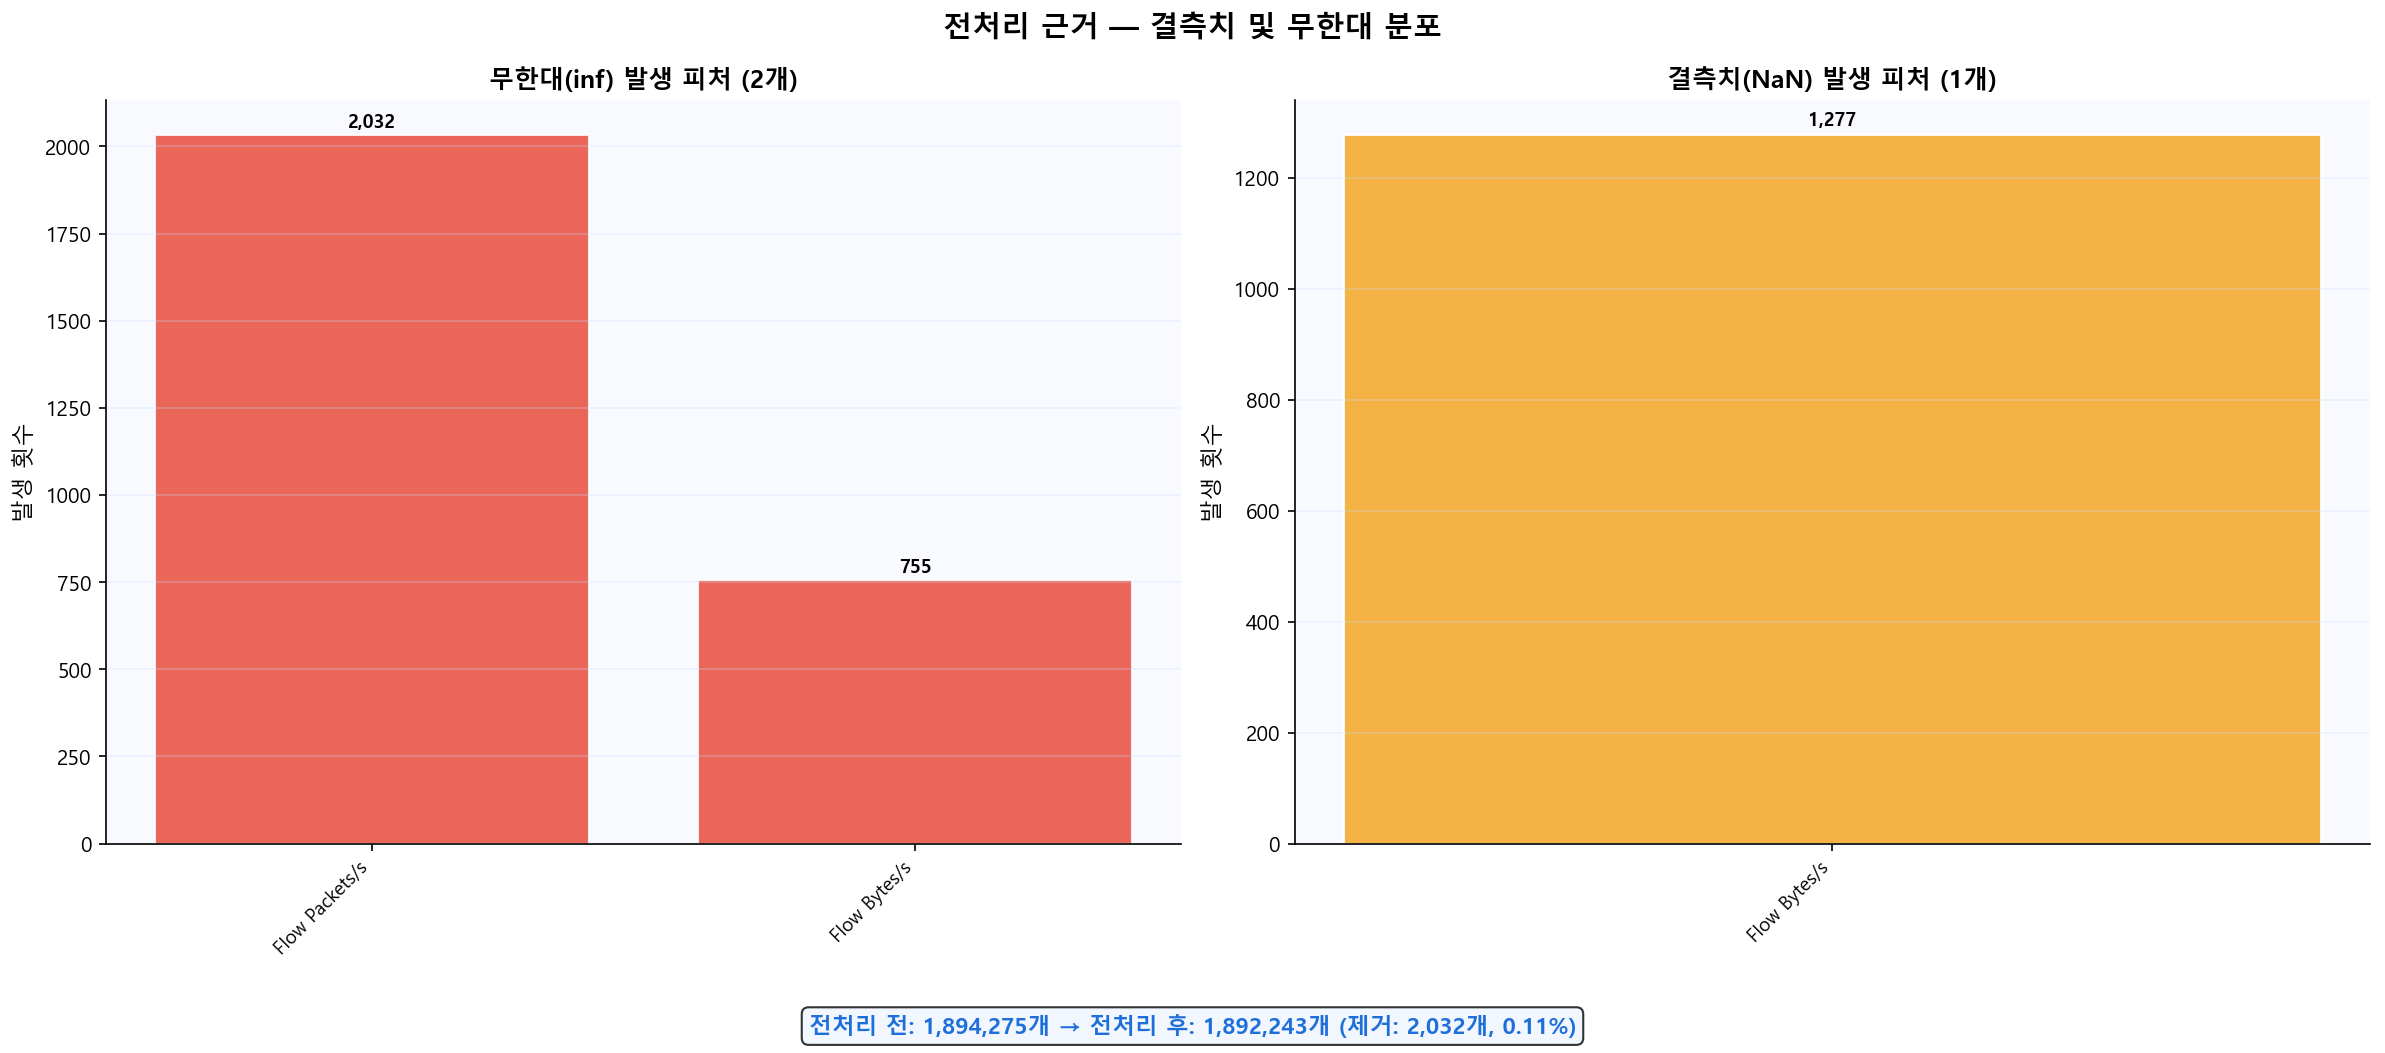

✅ EDA 3 저장 완료


In [6]:
# ── EDA 3. 결측치/무한대 분포 ────────────────────────────────
numeric_cols = raw.select_dtypes(include=[np.number]).columns.tolist()

inf_count = raw[numeric_cols].isin([np.inf, -np.inf]).sum()
nan_count = raw[numeric_cols].isna().sum()
inf_cols  = inf_count[inf_count > 0].sort_values(ascending=False)
nan_cols  = nan_count[nan_count > 0].sort_values(ascending=False)

total_rows = len(raw)
clean_rows = raw[numeric_cols].replace([np.inf, -np.inf], np.nan).dropna().__len__()
removed    = total_rows - clean_rows

print(f"무한대 발생 피처: {len(inf_cols)}개")
print(f"결측치 발생 피처: {len(nan_cols)}개")
print(f"제거 행: {removed:,}개 ({removed/total_rows*100:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('전처리 근거 — 결측치 및 무한대 분포', fontsize=14, fontweight='bold')
fig.patch.set_facecolor('white')

# ── 왼쪽: 무한대 ─────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor('#F8FAFF')
if len(inf_cols) > 0:
    bars = ax.bar(range(len(inf_cols)), inf_cols.values,
                  color='#E74C3C', alpha=0.85, edgecolor='white')
    ax.set_xticks(range(len(inf_cols)))
    ax.set_xticklabels(inf_cols.index, rotation=45, ha='right', fontsize=9)
    for bar, val in zip(bars, inf_cols.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(f'무한대(inf) 발생 피처 ({len(inf_cols)}개)', fontsize=12, fontweight='bold')
else:
    ax.text(0.5, 0.5, '무한대 값 없음', ha='center', va='center',
            fontsize=16, color='#27AE60', fontweight='bold')
    ax.set_title('무한대(inf) 발생 피처', fontsize=12, fontweight='bold')
ax.set_ylabel('발생 횟수', fontsize=11)
ax.grid(axis='y', alpha=0.3, color='#CCDDFF')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── 오른쪽: 결측치 ───────────────────────────────────────────
ax = axes[1]
ax.set_facecolor('#F8FAFF')
if len(nan_cols) > 0:
    bars = ax.bar(range(len(nan_cols)), nan_cols.values,
                  color='#F5A623', alpha=0.85, edgecolor='white')
    ax.set_xticks(range(len(nan_cols)))
    ax.set_xticklabels(nan_cols.index, rotation=45, ha='right', fontsize=9)
    for bar, val in zip(bars, nan_cols.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(f'결측치(NaN) 발생 피처 ({len(nan_cols)}개)', fontsize=12, fontweight='bold')
else:
    ax.text(0.5, 0.5, '결측치 없음', ha='center', va='center',
            fontsize=16, color='#27AE60', fontweight='bold')
    ax.set_title('결측치(NaN) 발생 피처', fontsize=12, fontweight='bold')
ax.set_ylabel('발생 횟수', fontsize=11)
ax.grid(axis='y', alpha=0.3, color='#CCDDFF')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.text(0.5, 0.01,
         f'전처리 전: {total_rows:,}개 → 전처리 후: {clean_rows:,}개 '
         f'(제거: {removed:,}개, {removed/total_rows*100:.2f}%)',
         ha='center', fontsize=11, fontweight='bold', color='#1E6FD9',
         bbox=dict(boxstyle='round', facecolor='#EEF4FF', alpha=0.8))

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig(VIS_DIR + 'eda3_missing_values.png', bbox_inches='tight', facecolor='white')
plt.show()
print("✅ EDA 3 저장 완료")

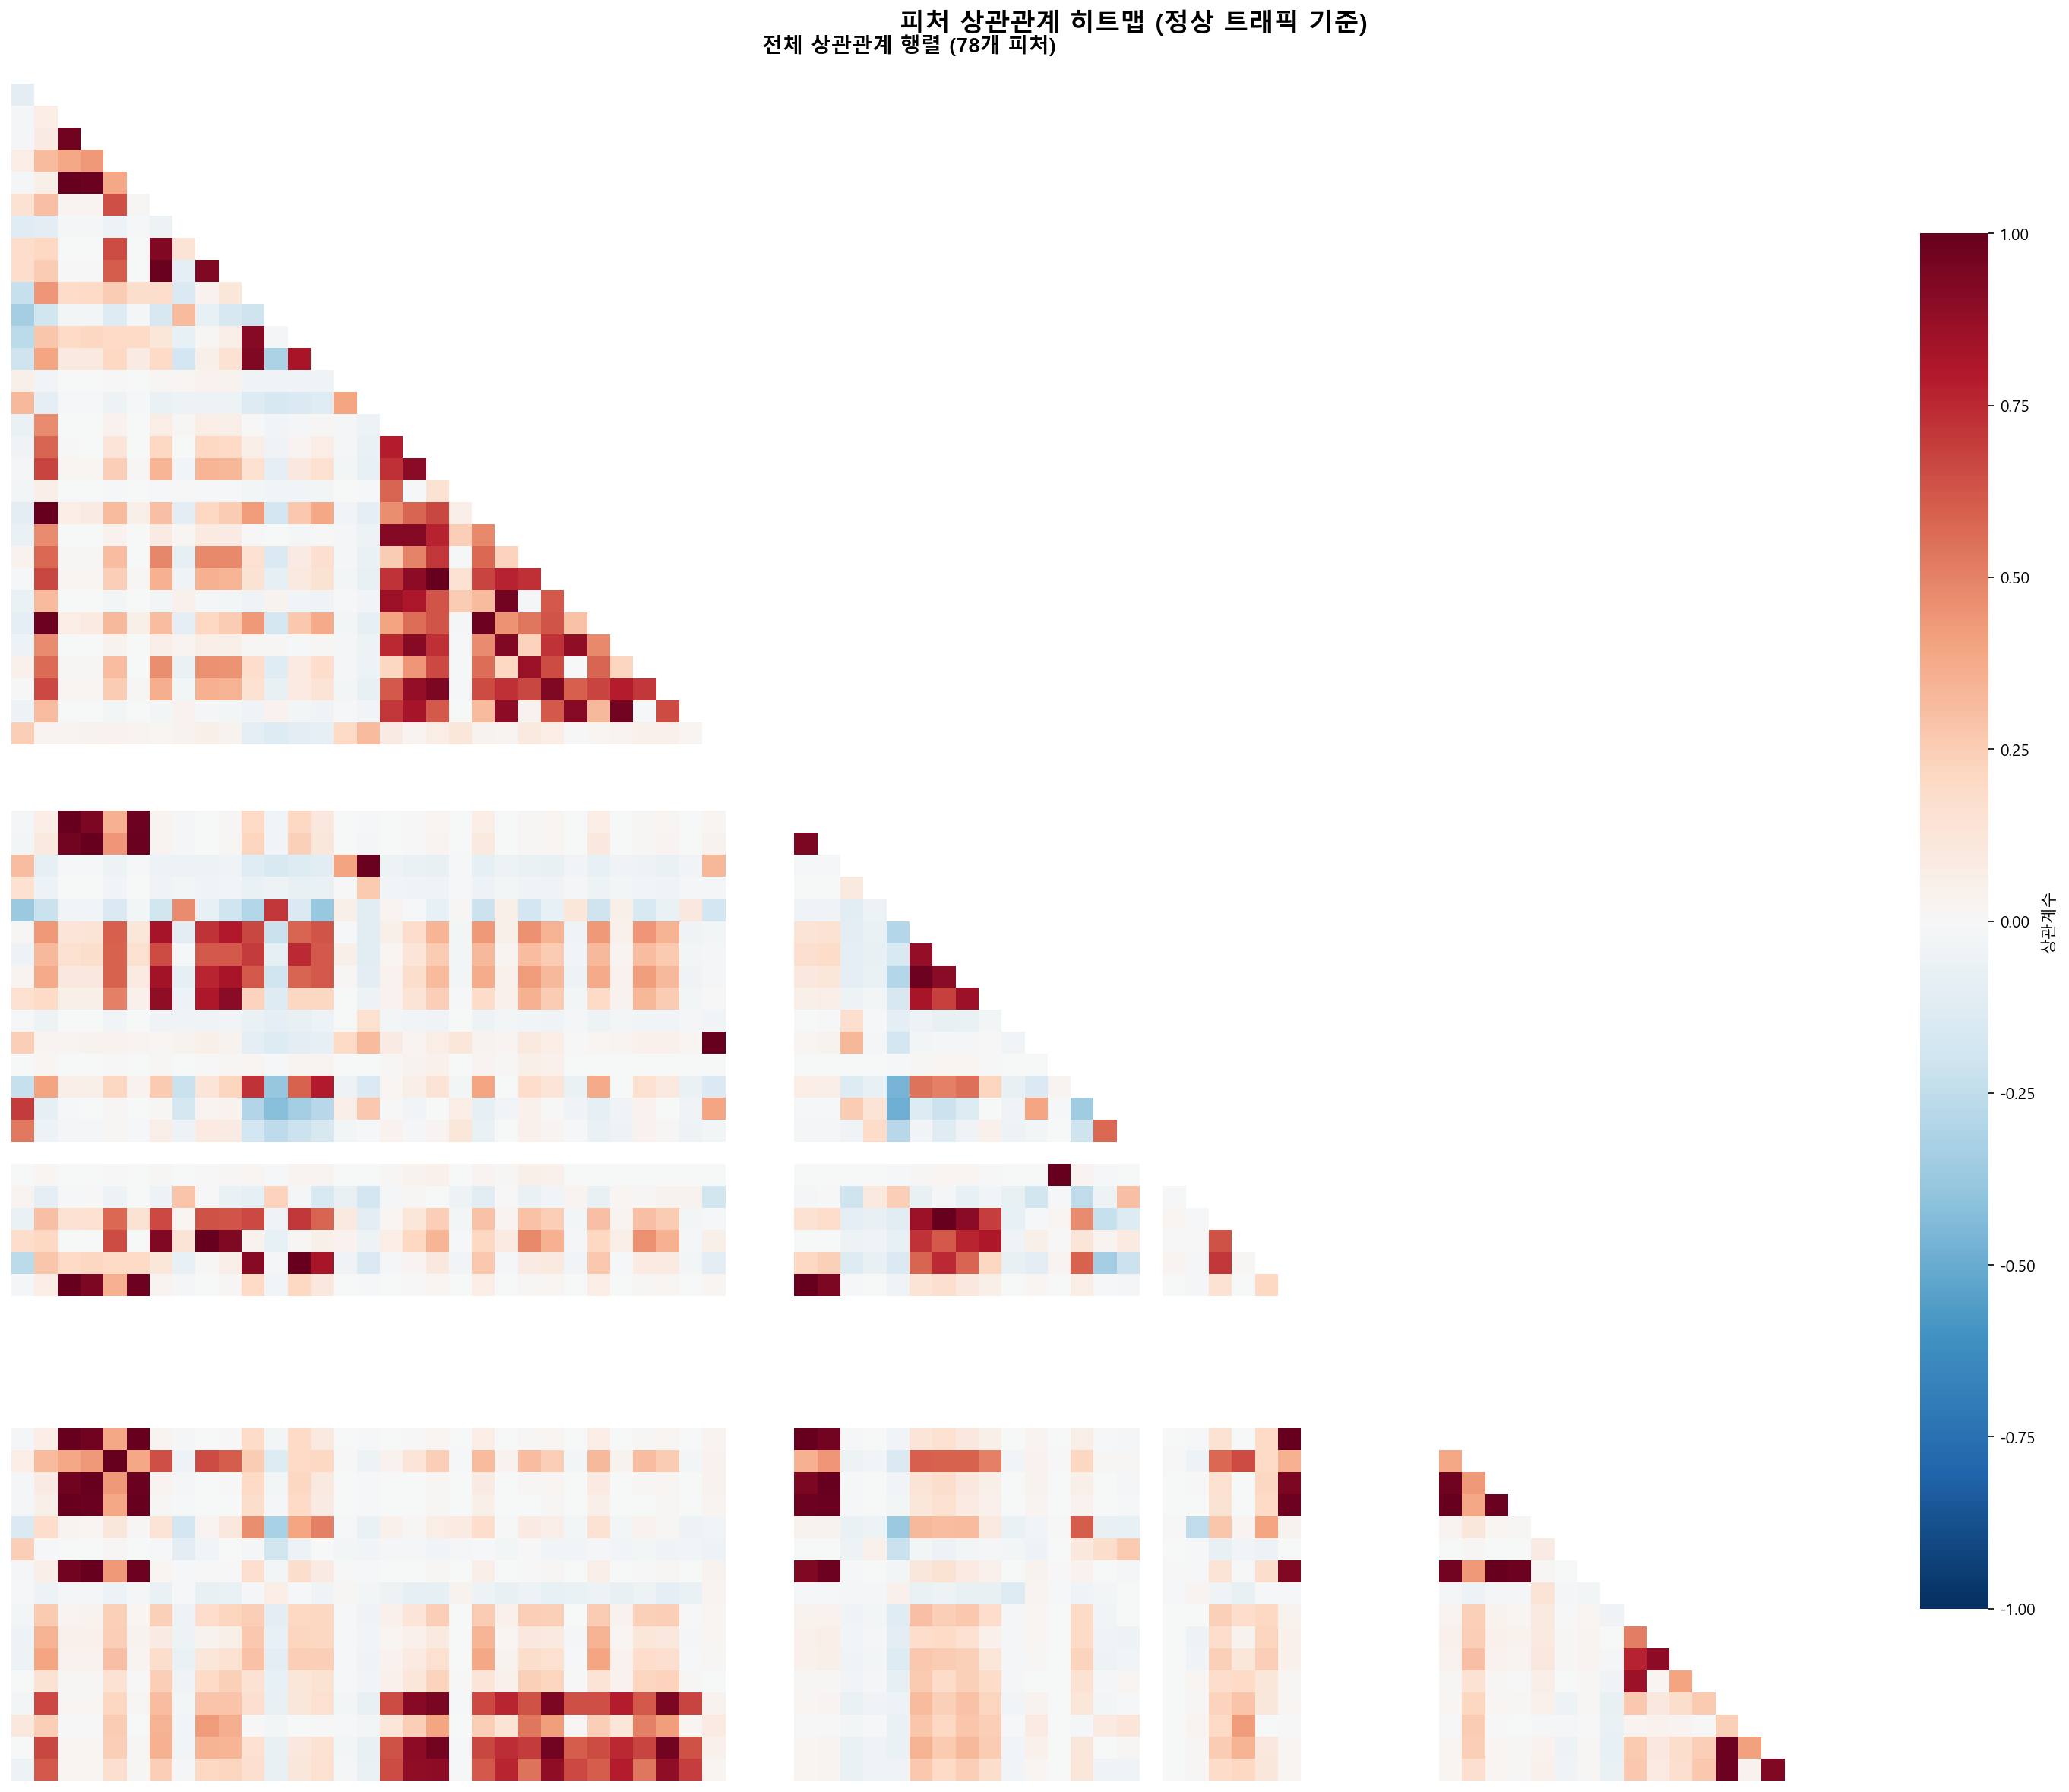

✅ EDA 4-1 저장 완료


In [7]:
# ── EDA 4-1. 상관관계 히트맵 ─────────────────────────────────
benign_sample = raw[raw['Label'] == 'BENIGN'][numeric_cols].sample(
    5000, random_state=42).replace([np.inf, -np.inf], np.nan).dropna()

corr_matrix = benign_sample.corr()

fig, ax = plt.subplots(figsize=(20, 16))
fig.suptitle('피처 상관관계 히트맵 (정상 트래픽 기준)',
             fontsize=16, fontweight='bold')
fig.patch.set_facecolor('white')

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
import seaborn as sns
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax,
            xticklabels=False, yticklabels=False,
            cbar_kws={'shrink': 0.8, 'label': '상관계수'})

ax.set_title(f'전체 상관관계 행렬 ({len(numeric_cols)}개 피처)',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(VIS_DIR + 'eda4_1_heatmap.png', bbox_inches='tight', facecolor='white')
plt.show()
print("✅ EDA 4-1 저장 완료")

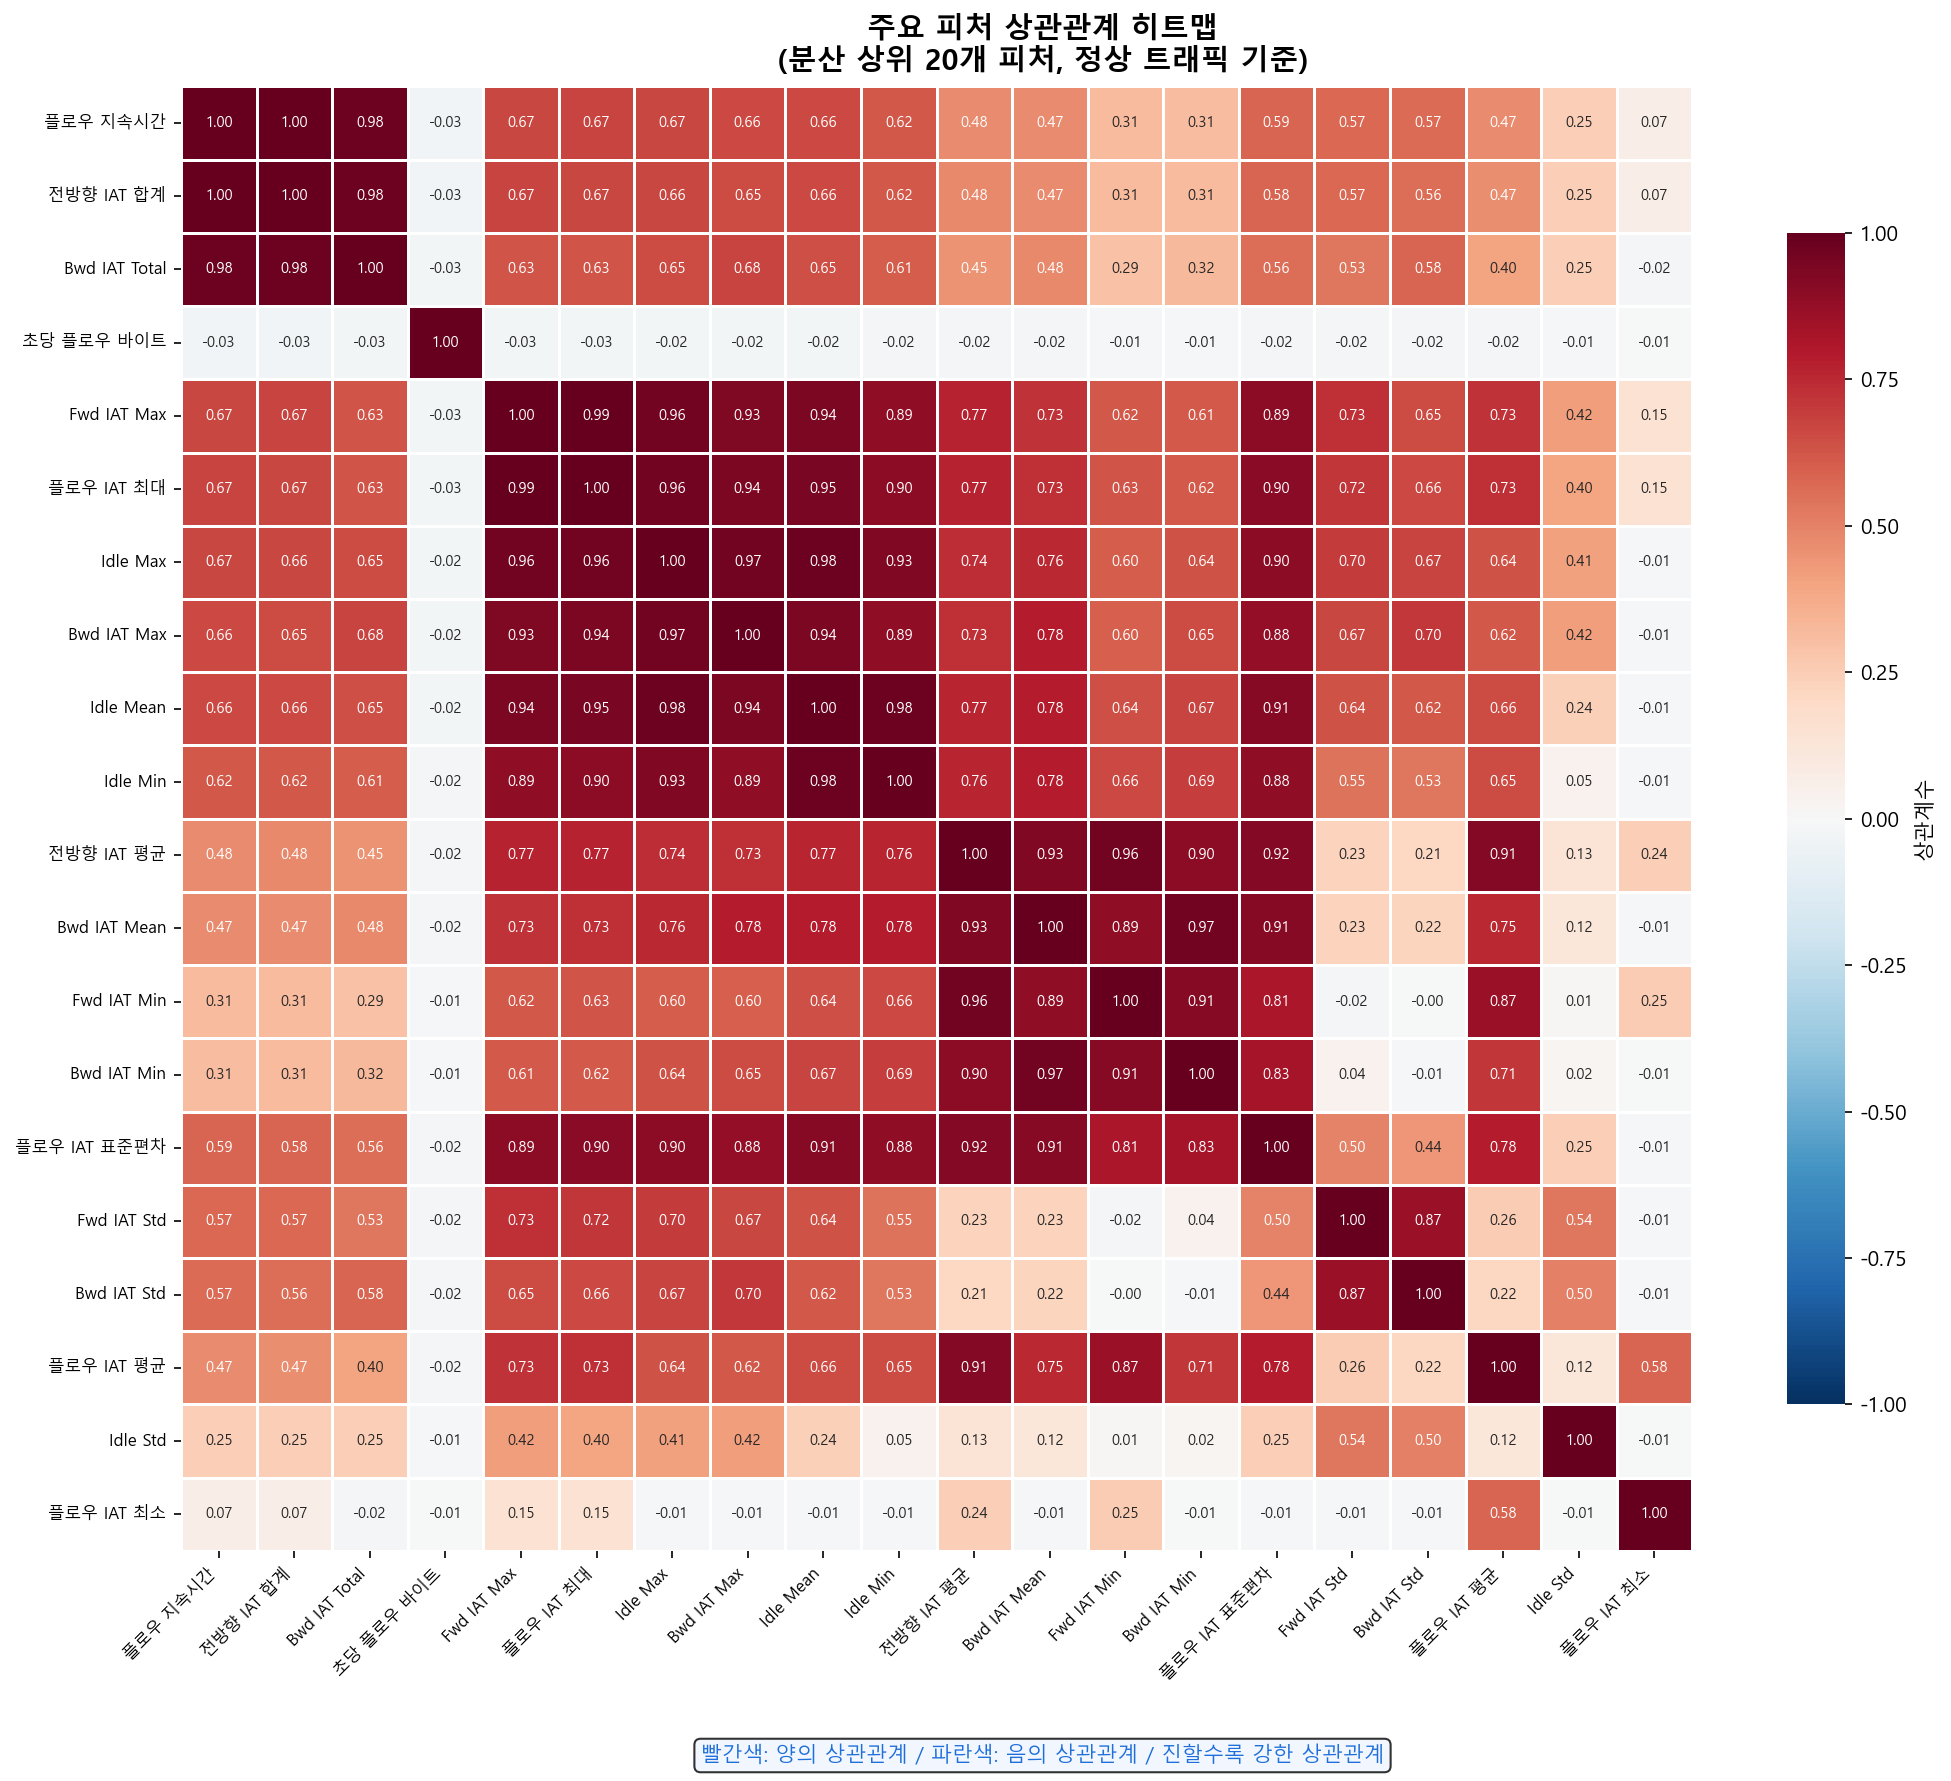

✅ EDA 4-1 저장 완료


In [9]:
# ── EDA 4-1. 상관관계 히트맵 (Top 20 피처) ───────────────────
import seaborn as sns

# 분산이 높은 피처 Top 20 선택
variance = benign_sample.var().sort_values(ascending=False)
top20_cols = variance.head(20).index.tolist()
corr_top20 = benign_sample[top20_cols].corr()

# 한글 피처명 매핑
feat_kr_map = {
    'Flow Duration':                '플로우 지속시간',
    'Total Fwd Packets':            '전방향 패킷 수',
    'Total Backward Packets':       '역방향 패킷 수',
    'Total Length of Fwd Packets':  '전방향 패킷 총길이',
    'Total Length of Bwd Packets':  '역방향 패킷 총길이',
    'Fwd Packet Length Max':        '전방향 패킷 최대길이',
    'Fwd Packet Length Min':        '전방향 패킷 최소길이',
    'Fwd Packet Length Mean':       '전방향 패킷 평균길이',
    'Bwd Packet Length Max':        '역방향 패킷 최대길이',
    'Bwd Packet Length Min':        '역방향 패킷 최소길이',
    'Bwd Packet Length Mean':       '역방향 패킷 평균길이',
    'Flow Bytes/s':                 '초당 플로우 바이트',
    'Flow Packets/s':               '초당 플로우 패킷',
    'Flow IAT Mean':                '플로우 IAT 평균',
    'Flow IAT Std':                 '플로우 IAT 표준편차',
    'Flow IAT Max':                 '플로우 IAT 최대',
    'Flow IAT Min':                 '플로우 IAT 최소',
    'Fwd IAT Total':                '전방향 IAT 합계',
    'Fwd IAT Mean':                 '전방향 IAT 평균',
    'Average Packet Size':          '평균 패킷 크기',
}

labels = [feat_kr_map.get(c, c[:15]) for c in corr_top20.columns]

fig, ax = plt.subplots(figsize=(14, 12))
fig.suptitle('주요 피처 상관관계 히트맵\n(분산 상위 20개 피처, 정상 트래픽 기준)',
             fontsize=14, fontweight='bold')
fig.patch.set_facecolor('white')

sns.heatmap(corr_top20, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax,
            xticklabels=labels, yticklabels=labels,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            cbar_kws={'shrink': 0.8, 'label': '상관계수'},
            linewidths=0.5, linecolor='white')

ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(labels, rotation=0, fontsize=8)

fig.text(0.5, 0.01,
         '빨간색: 양의 상관관계 / 파란색: 음의 상관관계 / 진할수록 강한 상관관계',
         ha='center', fontsize=10, color='#1E6FD9',
         bbox=dict(boxstyle='round', facecolor='#EEF4FF', alpha=0.8))

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(VIS_DIR + 'eda4_1_heatmap_v2.png', bbox_inches='tight', facecolor='white')
plt.show()
print("✅ EDA 4-1 저장 완료")

상관계수 > 0.95 피처 쌍: 57개


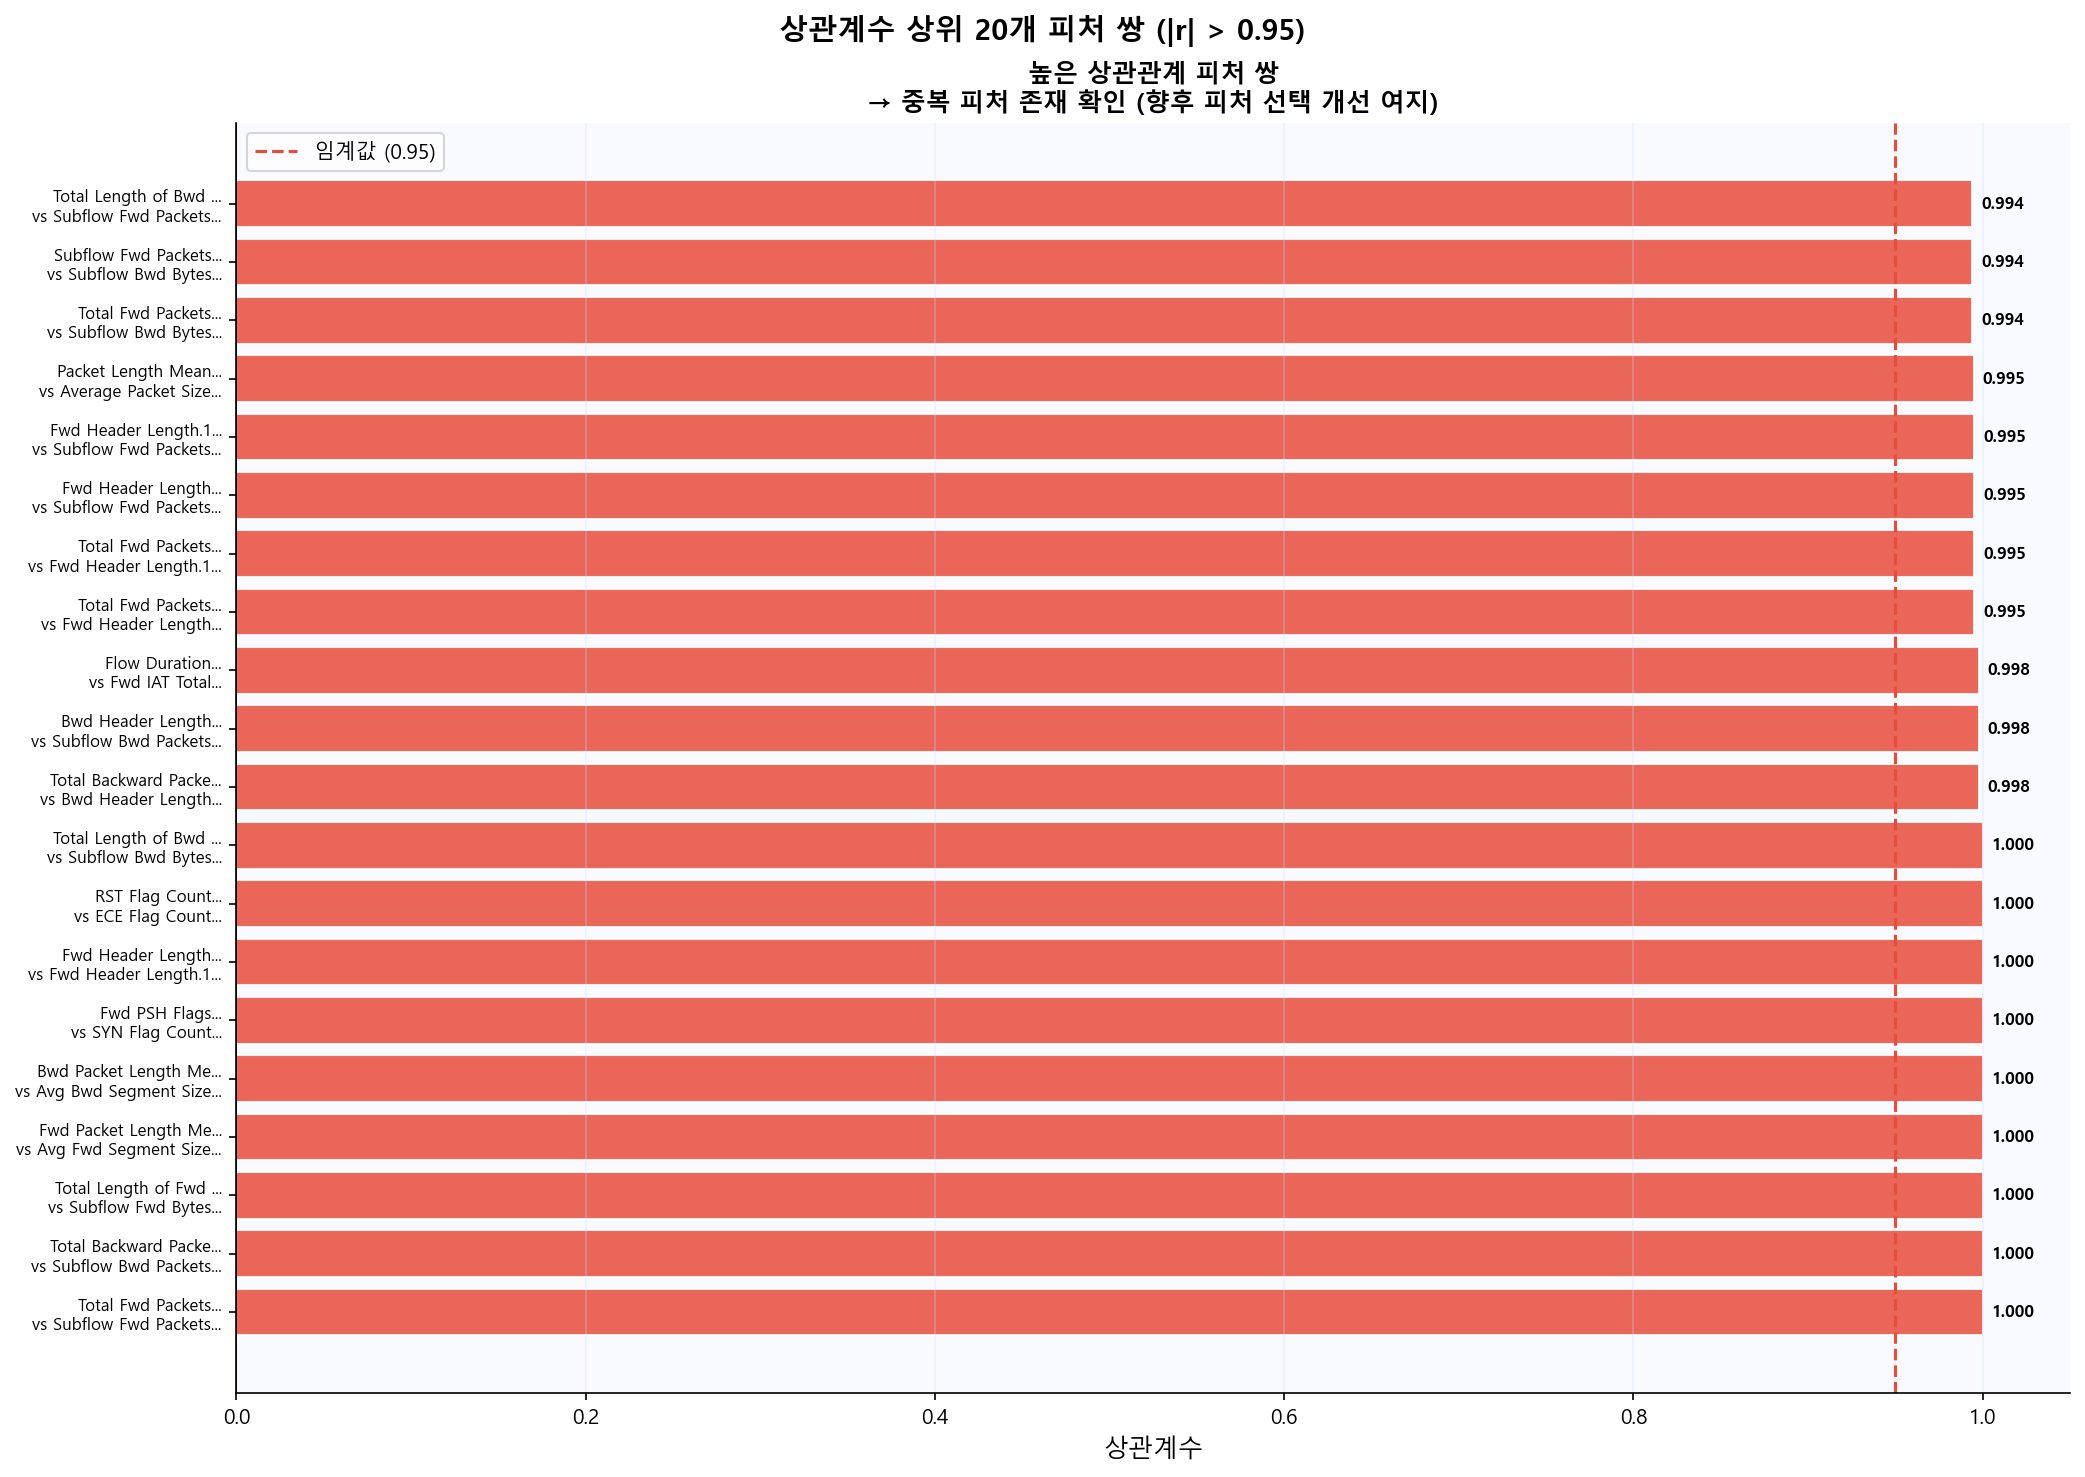

✅ EDA 4-2 저장 완료


In [8]:
# ── EDA 4-2. 고상관 피처 쌍 막대 그래프 ─────────────────────
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.95:
            high_corr.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

print(f"상관계수 > 0.95 피처 쌍: {len(high_corr)}개")

top_corr = sorted(high_corr, key=lambda x: abs(x[2]), reverse=True)[:20]

pairs = [f"{a[:20]}...\nvs {b[:20]}..." for a, b, _ in top_corr]
vals  = [c for _, _, c in top_corr]

fig, ax = plt.subplots(figsize=(14, 10))
fig.suptitle('상관계수 상위 20개 피처 쌍 (|r| > 0.95)',
             fontsize=14, fontweight='bold')
fig.patch.set_facecolor('white')
ax.set_facecolor('#F8FAFF')

colors3 = ['#E74C3C' if v > 0 else '#1E6FD9' for v in vals]
bars = ax.barh(range(len(pairs)), vals,
               color=colors3, alpha=0.85, edgecolor='white')

ax.set_yticks(range(len(pairs)))
ax.set_yticklabels(pairs, fontsize=8)
ax.set_xlabel('상관계수', fontsize=12)
ax.set_title('높은 상관관계 피처 쌍\n→ 중복 피처 존재 확인 (향후 피처 선택 개선 여지)',
             fontsize=12, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(0.95, color='#E74C3C', linewidth=1.5,
           linestyle='--', label='임계값 (0.95)')
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.3, color='#CCDDFF')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, val in zip(bars, vals):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig(VIS_DIR + 'eda4_2_high_correlation.png', bbox_inches='tight', facecolor='white')
plt.show()
print("✅ EDA 4-2 저장 완료")

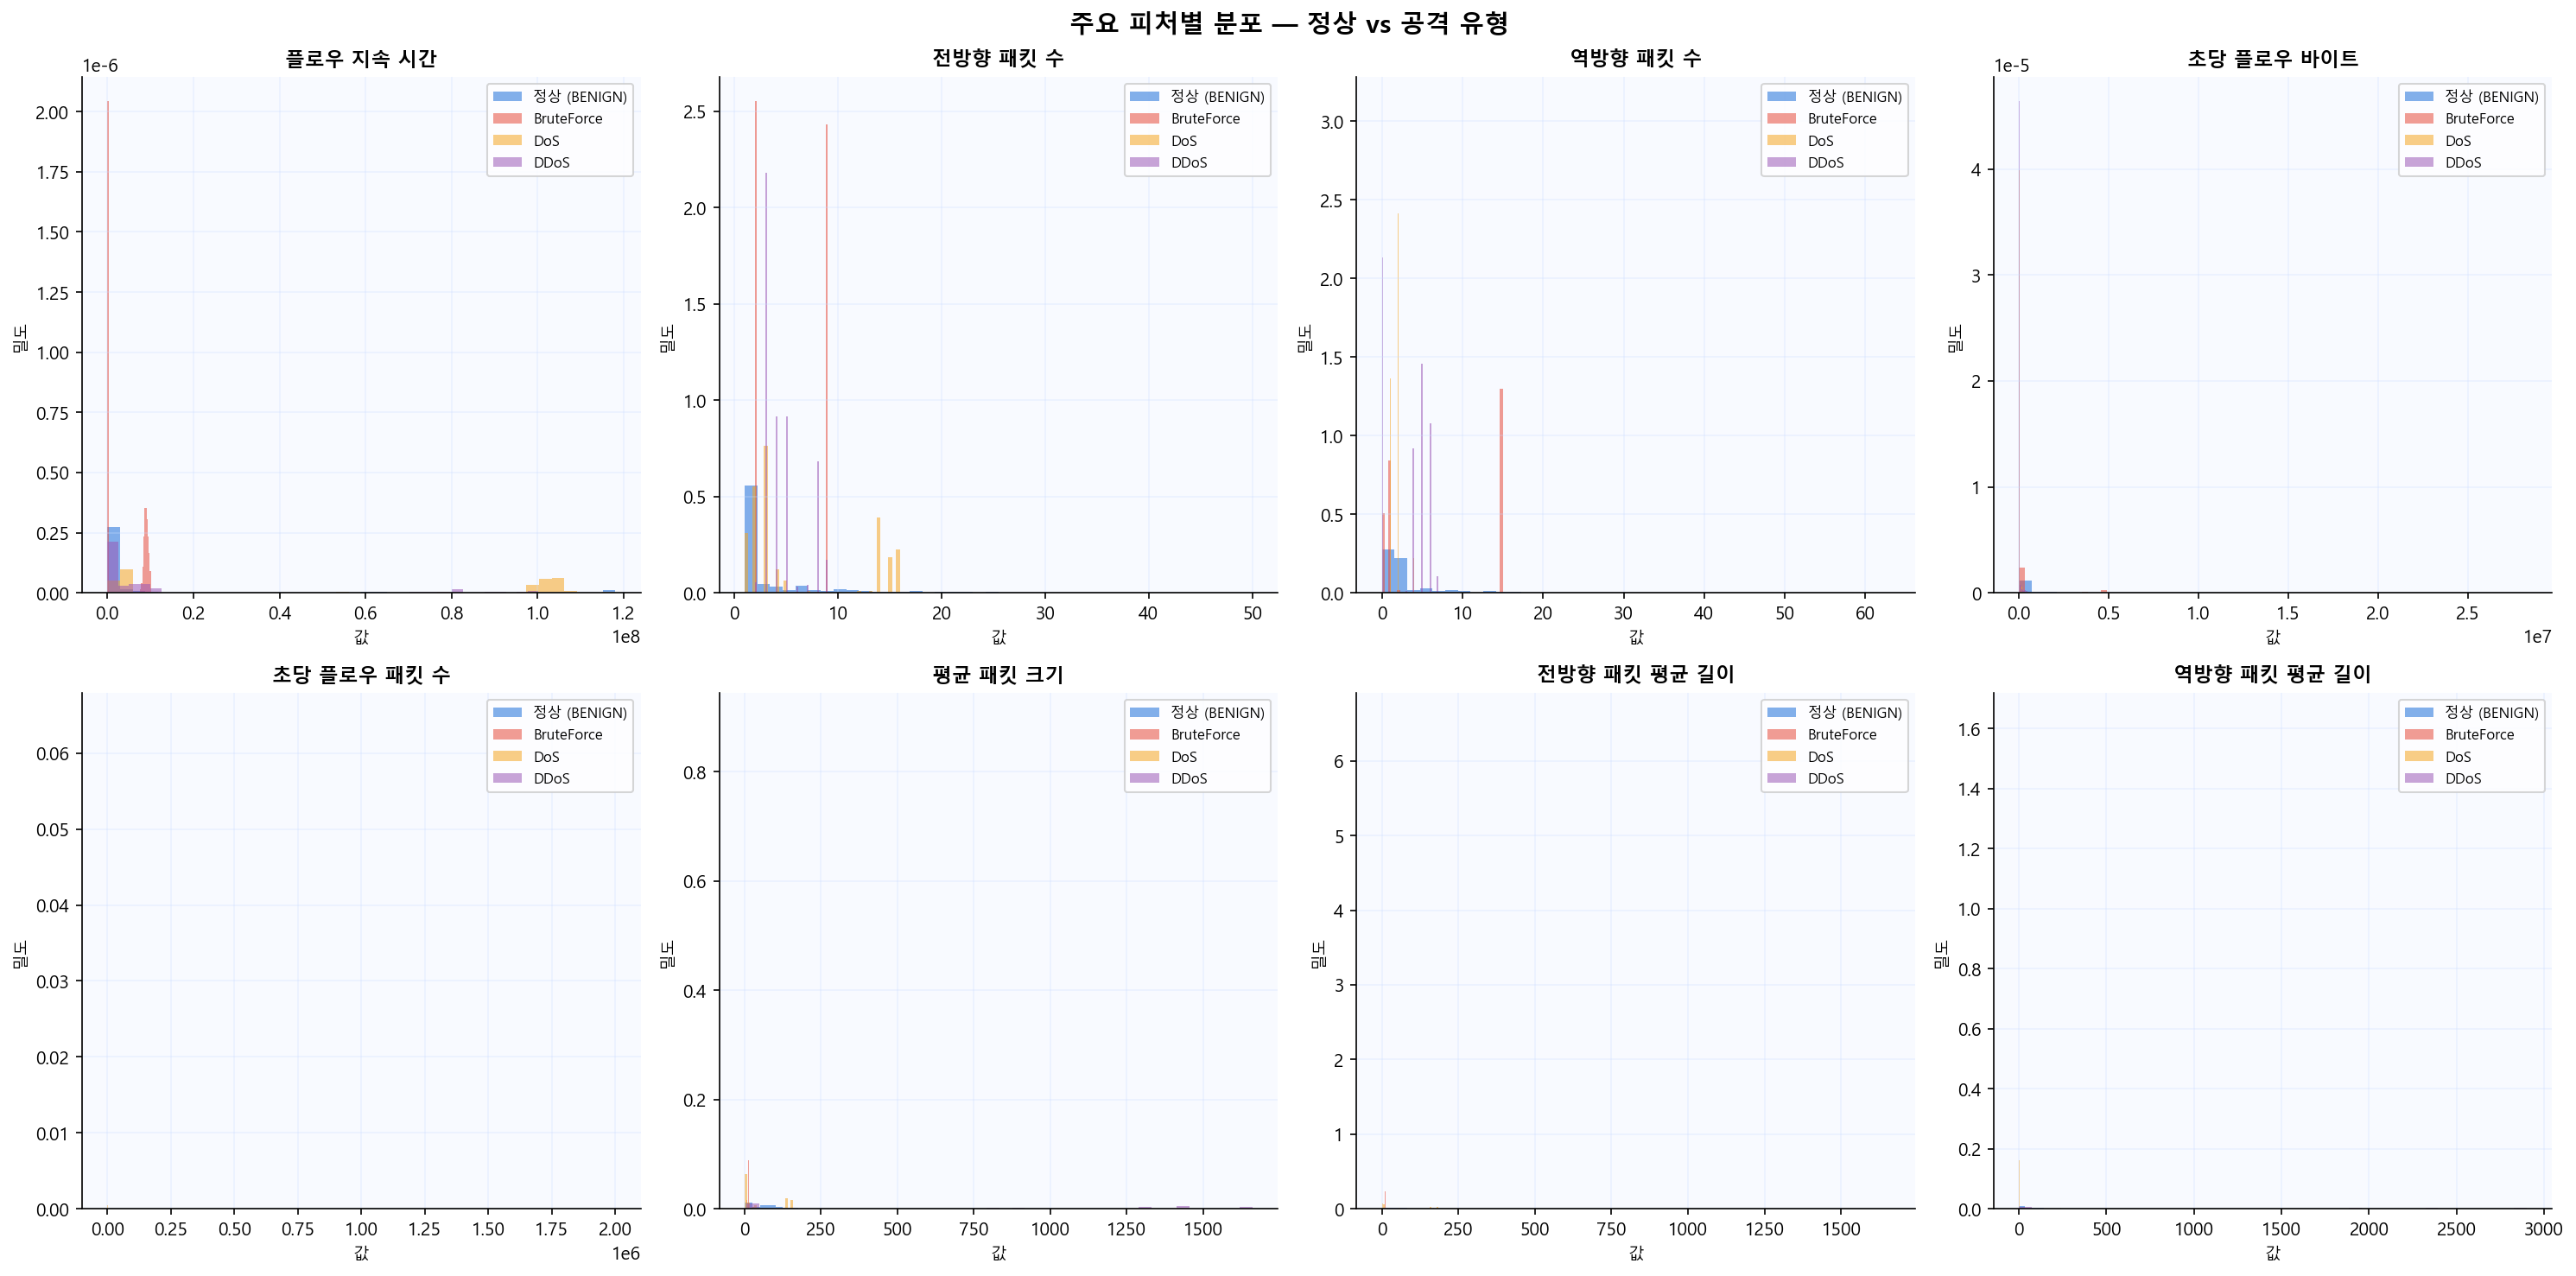

✅ EDA 5 저장 완료


In [10]:
# ── EDA 5. 주요 피처별 분포도 ────────────────────────────────
top_features = {
    'Flow Duration':          '플로우 지속 시간',
    'Total Fwd Packets':      '전방향 패킷 수',
    'Total Backward Packets': '역방향 패킷 수',
    'Flow Bytes/s':           '초당 플로우 바이트',
    'Flow Packets/s':         '초당 플로우 패킷 수',
    'Average Packet Size':    '평균 패킷 크기',
    'Fwd Packet Length Mean': '전방향 패킷 평균 길이',
    'Bwd Packet Length Mean': '역방향 패킷 평균 길이',
}
top_features = {k: v for k, v in top_features.items() if k in raw.columns}

plot_data = {
    '정상 (BENIGN)': raw[raw['Label'] == 'BENIGN'].sample(3000, random_state=42),
    'BruteForce':    raw[raw['Label'] == 'FTP-Patator'].sample(
                         min(3000, (raw['Label']=='FTP-Patator').sum()), random_state=42),
    'DoS':           raw[raw['Label'] == 'DoS slowloris'].sample(
                         min(3000, (raw['Label']=='DoS slowloris').sum()), random_state=42),
    'DDoS':          raw[raw['Label'] == 'DDoS'].sample(
                         min(3000, (raw['Label']=='DDoS').sum()), random_state=42),
}

colors_map = {
    '정상 (BENIGN)': '#1E6FD9',
    'BruteForce':    '#E74C3C',
    'DoS':           '#F5A623',
    'DDoS':          '#9B59B6'
}

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('주요 피처별 분포 — 정상 vs 공격 유형',
             fontsize=14, fontweight='bold')
fig.patch.set_facecolor('white')

for idx, (feat, feat_kr) in enumerate(top_features.items()):
    ax = axes[idx // 4][idx % 4]
    ax.set_facecolor('#F8FAFF')

    for label, df_s in plot_data.items():
        if feat in df_s.columns:
            data = df_s[feat].replace([np.inf, -np.inf], np.nan).dropna()
            clip = np.percentile(data, 99)
            data = data[data <= clip]
            ax.hist(data, bins=40, alpha=0.55,
                    color=colors_map[label], label=label, density=True)

    ax.set_title(feat_kr, fontsize=11, fontweight='bold')
    ax.set_xlabel('값', fontsize=9)
    ax.set_ylabel('밀도', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, color='#CCDDFF')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(VIS_DIR + 'eda5_feature_distribution.png', bbox_inches='tight', facecolor='white')
plt.show()
print("✅ EDA 5 저장 완료")